# **Spring Week 5: Computer Vision**

We will be training our own AlexNet model today.

# 1. AlexNet

In [1]:
! pip3 install tensorflow
! pip3 install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import tensorflow as tf # we will use tensorflow to build and train NNs
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt # to visualize

## 1.1 Let's get our data! 

CIFAR-10 contains 60,000 32×32 RGB images across 10 classes. For tensorflow, the pixel values in the dataset need to be normalized to being between 0 and 1. Additionally, we need to one-hot encoded our labels for softmax classification.

In [ ]:
# In case of the SSL Certification Error, run this!
# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

In [ ]:
# Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


## 1.2 Defining the AlexNet Model (Adjusted for CIFAR-10)

When training a model, we must ensure that our model's layers fit for our data size. What are the dimensions of our data?

In [8]:
x_test[0].shape

(32, 32, 3)

### 1.2.1 Let's define our model!

- Our model must handle 32 by 32 images with 10 output classes.
- We use reduced FC layers to prevents overfitting on our small dataset.
- As per AlexNet, our model uses ReLU, Dropout, BatchNorm and softmax in the final layer.

In [9]:
model = Sequential()

# Layer 1
model.add(Conv2D(96, kernel_size=(3,3), strides=(1,1), input_shape=(32,32,3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# Layer 2
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# Layer 3
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))

# Layer 4
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))

# Layer 5
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer 1
model.add(Dense(1024))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Fully Connected Layer 2
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10))
model.add(Activation('softmax'))

/Users/shreyanakum/Documents/Workshops-Code-2627/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 1.3 Compiling the Model

We use the adam optimizer and categorical_crossentropy for multi-class classification.

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## 1.4 Training the Model

Since we have a smaller dataset, we should typically train for a higher number of epochs, but that will take too long so we will stick with 10 epochs with a 20% validation split. 

In [ ]:
history = model.fit(x_train, y_train, 
                    batch_size= 128, # 128, 
                    epochs=10,
                    validation_split=0.5, # 0.8 = 23 minutes
                    verbose=1)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.5362 - loss: 1.2688 - val_accuracy: 0.4796 - val_loss: 1.4593
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.5975 - loss: 1.1175 - val_accuracy: 0.5562 - val_loss: 1.2677
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.6530 - loss: 0.9688 - val_accuracy: 0.5651 - val_loss: 1.2571
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.7012 - loss: 0.8391 - val_accuracy: 0.6016 - val_loss: 1.2045
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.7471 - loss: 0.7022 - val_accuracy: 0.5988 - val_loss: 1.2104
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.7714 - loss: 0.6333 - val_accuracy: 0.5692 - val_loss: 1.5409
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.8103 - loss: 0.5357 - val_accuracy: 0.5972 - val_loss: 1.3353
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.8392 - loss: 0.4480 - val_accuracy: 0.5698 - v

## 1.5 Evaluating the Model

Let's see how the model does on our earlier held-off test set.

In [20]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc}')

Test Accuracy: 0.5735999941825867


## 1.6 Plotting Training & Validation Accuracy

As time goes on, we can see the model improve in its performance through Tensorflow's history.

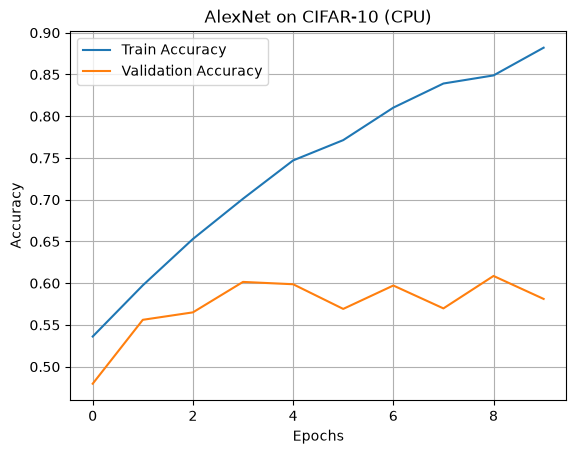

In [22]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('AlexNet on CIFAR-10 (CPU)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 2. iSpy: Model-free Object Detection

In [23]:
! pip3 install opencv-python


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [26]:
import cv2
import matplotlib.pyplot as plt

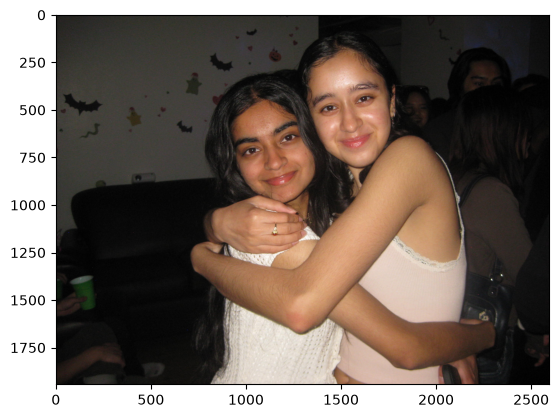

In [29]:
img = cv2.imread('tin_min.jpeg')

# Plot in plt, convert to RGB

rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img)

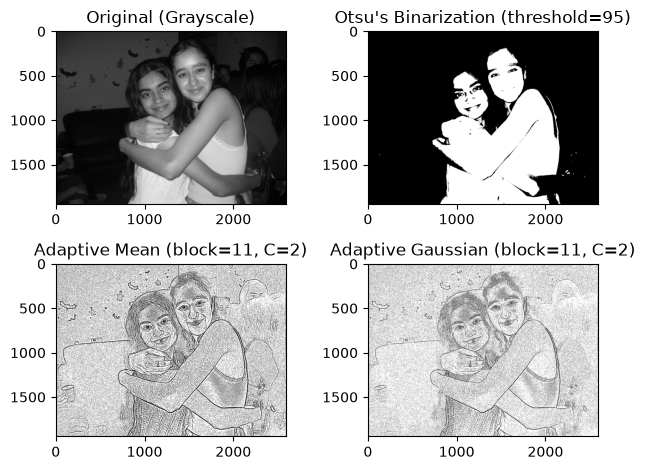

In [30]:
# We need to separate jasmine from the background
# First, let's try some thresholding techniques, like in the slides

img_gs = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

otsu_val, otsu_thresh = cv2.threshold(img_gs, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
adapt_mean = cv2.adaptiveThreshold(img_gs, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
adapt_gauss = cv2.adaptiveThreshold(img_gs, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

plt.subplot(2, 2, 1)
plt.title('Original (Grayscale)')
plt.imshow(img_gs, cmap='gray')

plt.subplot(2, 2, 2)
plt.title(f"Otsu's Binarization (threshold={int(otsu_val)})")
plt.imshow(otsu_thresh, cmap='gray')

plt.subplot(2, 2, 3)
plt.title('Adaptive Mean (block=11, C=2)')
plt.imshow(adapt_mean, cmap='gray')

plt.subplot(2, 2, 4)
plt.title('Adaptive Gaussian (block=11, C=2)')
plt.imshow(adapt_gauss, cmap='gray')

plt.tight_layout()

# 3. Semantic Segmentation with PyTorch